## Modelo RamdonForest para regresión

El bosque de arboles de decisión tiene un doble proposito 
1) Permitir identificar las variables mas relevantes de nuestro conjunto de datos 
2) Predecir el precio (`Tarifa`) del servicio * usario

## Corrrelaciones vs Relevancia

In [7]:
# Librerías necesarias
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path
plt.style.use('ggplot')

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [8]:
# Definimos la ruta a los datos desde src hacia data
proyecto_root = Path.cwd().parent
ruta_X = proyecto_root / "data" / "X_modelo.csv"
ruta_y = proyecto_root / "data" / "y_modelo.csv"

# Cargar las bases de datos
X = pd.read_csv(ruta_X)
y = pd.read_csv(ruta_y)

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)
X.head()

Dimensiones de X: (260853, 14)
Dimensiones de y: (260853, 1)


,edad,CANCER,DIABETES,ENF_CARDIACA,HIPERTENSION,ENF_PULMONAR,num_condiciones,meses_expuesto_total,Sexo_Cd_limpio_M,Sexo_Cd_limpio_NOBINARIO,CIUDAD_NORM_CALI,CIUDAD_NORM_CARTAGENA,CIUDAD_NORM_MEDELLIN,CIUDAD_NORM_SIN INFORMACION
0,57,0,0,0,0,0,0,11.991786,False,False,False,False,True,False
1,14,0,0,0,0,0,0,11.991786,True,False,False,False,True,False
2,11,0,0,0,0,0,0,11.991786,False,False,False,False,True,False
3,36,0,0,0,0,0,0,11.991786,False,False,False,True,False,False
4,16,0,0,0,0,0,0,11.991786,True,False,True,False,False,False


In [9]:
print("Dividiendo los datos y Entrenando Random Forest")

# Aseguramos  que 'y' sea un array 1D 
y_target = y['total_pagado'] if 'total_pagado' in y.columns else y.values.ravel()

#Dividimos los datos en 80% para entrenamiento y 20% para validación
X_train, X_val, y_train, y_val = train_test_split(X, y_target, test_size=0.2, random_state=42)

# 2. Entrenamos el modelo SOLO con los datos de entrenamiento (X_train)
rf_inicial = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_inicial.fit(X_train, y_train)


Dividiendo los datos y Entrenando Random Forest


RandomForestRegressor(n_jobs=-1, random_state=42)

# ANÁLISIS DE COMPLEJIDAD: ENCONTRAR EL max_depth ÓPTIMO 

Este paso prueba árboles con diferentes profundidades para encontrar el equilibrio entre aprender bien (bajo error de entrenamiento) y generalizar (bajo error de validación)

Analizando complejidad del modelo (Overfitting/Underfitting)...


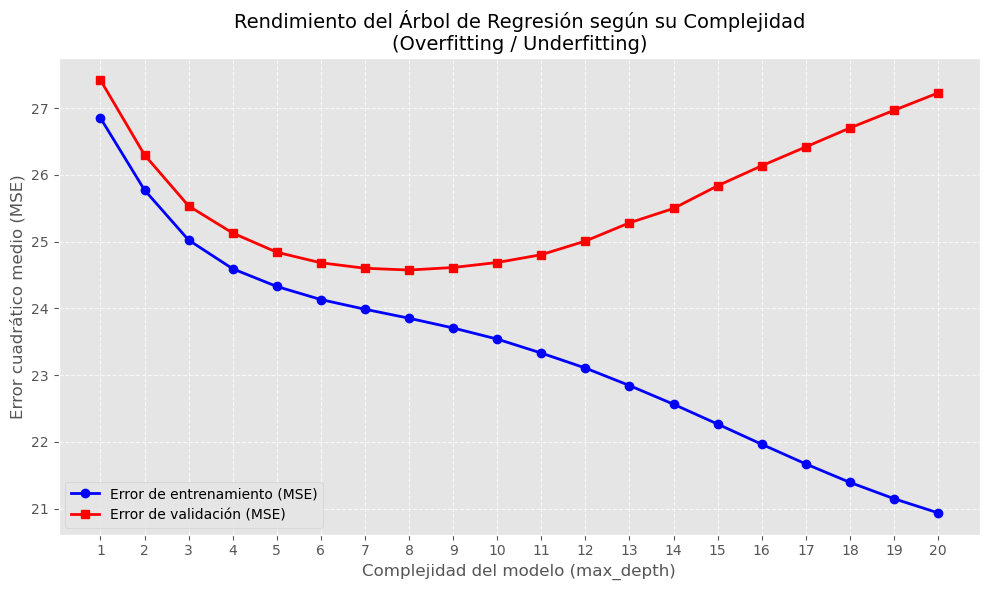


Profundidad óptima del árbol: 8
MSE de validación con profundidad óptima: 24.5734


In [10]:

print("Analizando complejidad del modelo (Overfitting/Underfitting)...")

# Probamos profundidades desde 1 hasta 20
depths = np.arange(1, 21)
train_errors = []
val_errors = []

for depth in depths:
    # Crear árbol con esa profundidad específica
    tree = DecisionTreeRegressor(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    
    # Hacer predicciones en entrenamiento y validación
    y_train_pred = tree.predict(X_train)
    y_val_pred = tree.predict(X_val)
    
    # Calcular errores (MSE = Mean Squared Error)
    train_mse = mean_squared_error(y_train, y_train_pred)
    val_mse = mean_squared_error(y_val, y_val_pred)
    
    train_errors.append(train_mse)
    val_errors.append(val_mse)

# Graficar los resultados
plt.figure(figsize=(10, 6))
plt.plot(depths, train_errors, 'o-', label='Error de entrenamiento (MSE)', color='blue', linewidth=2)
plt.plot(depths, val_errors, 's-', label='Error de validación (MSE)', color='red', linewidth=2)
plt.xlabel('Complejidad del modelo (max_depth)', fontsize=12)
plt.ylabel('Error cuadrático medio (MSE)', fontsize=12)
plt.title('Rendimiento del Árbol de Regresión según su Complejidad\n(Overfitting / Underfitting)', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(depths)
plt.tight_layout()
plt.show()

# Encontrar el max_depth óptimo (donde val_errors es más bajo)
optimal_depth = depths[np.argmin(val_errors)]
print(f"\nProfundidad óptima del árbol: {optimal_depth}")
print(f"MSE de validación con profundidad óptima: {np.min(val_errors):.4f}")


# COMPARACIÓN: CORRELACIÓN vs RELEVANCIA (Feature Importance) 

Correlación mide relaciones LINEALES, pero Feature Importance mide relaciones de CUALQUIER tipo (lineal, no-lineal, complejas)

## Observación
Si una variable tiene ALTA Relevancia pero BAJA Correlación,
significa que tiene una relación NO-LINEAL con el objetivo.




Calculando Correlación (Pearson) y Relevancia (Feature Importance)...

COMPARACIÓN: Correlación vs Relevancia


,Correlación (Abs),Relevancia (Árbol)
CANCER,0.062704,0.002029
CIUDAD_NORM_CALI,0.017937,0.021533
CIUDAD_NORM_CARTAGENA,0.027244,0.019857
CIUDAD_NORM_MEDELLIN,0.082145,0.022967
CIUDAD_NORM_SIN INFORMACION,0.010811,0.001145
DIABETES,0.047173,0.001427
ENF_CARDIACA,0.078185,0.002161
ENF_PULMONAR,0.056151,0.001001
HIPERTENSION,0.164493,0.002679
Sexo_Cd_limpio_M,0.140538,0.073958


/var/folders/wz/5knc4f1j3y1g1v82hm80x7g00000gn/T/ipykernel_40092/3200955628.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparativa['Correlación (Abs)'], y=comparativa.index, ax=ax[0], palette='Blues_r')
/var/folders/wz/5knc4f1j3y1g1v82hm80x7g00000gn/T/ipykernel_40092/3200955628.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparativa['Relevancia (Árbol)'], y=comparativa.index, ax=ax[1], palette='Greens_r')


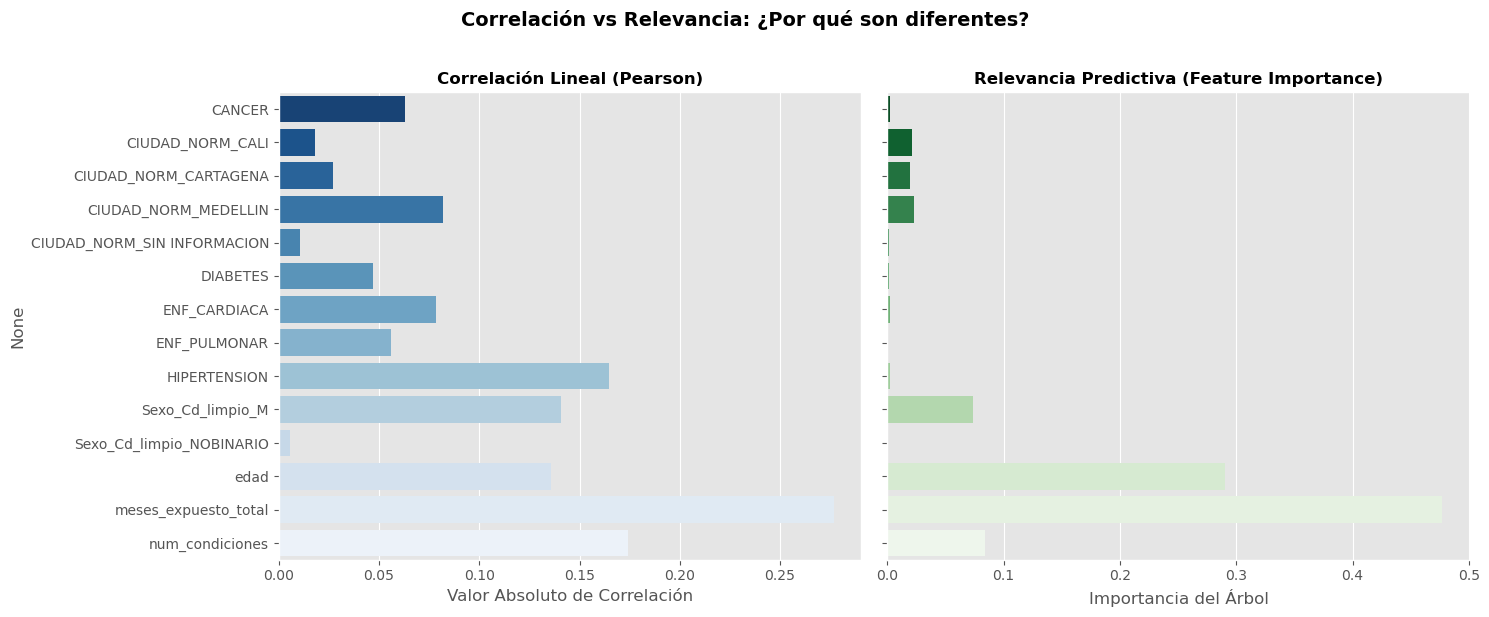


💡 OBSERVACIÓN:
Si una variable tiene ALTA Relevancia pero BAJA Correlación,
significa que tiene una relación NO-LINEAL con el objetivo.
¡Estos son los descubrimientos más valiosos del machine learning!


In [ ]:
print("Calculando Correlación (Pearson) y Relevancia (Feature Importance)...\n")

# 1. Calcular Correlación de Pearson con el objetivo (tomando valor absoluto)
# porque nos interesa la FUERZA de la relación, sea positiva o negativa
correlacion = X.corrwith(y_target).abs().sort_values(ascending=False)

# 2. Extraer Feature Importance del Random Forest entrenado
relevancia = pd.Series(
    rf_inicial.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# 3. Crear DataFrame comparativo
comparativa = pd.DataFrame({
    'Correlación (Abs)': correlacion,
    'Relevancia (Árbol)': relevancia
}).fillna(0)

print("=" * 70)
print("COMPARACIÓN: Correlación vs Relevancia")
print("=" * 70)
display(comparativa)

# 4. Visualización comparativa
fig, ax = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Gráfico de Correlación
sns.barplot(x=comparativa['Correlación (Abs)'], y=comparativa.index, ax=ax[0], palette='Blues_r')
ax[0].set_title('Correlación Lineal (Pearson)', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Valor Absoluto de Correlación')

# Gráfico de Relevancia
sns.barplot(x=comparativa['Relevancia (Árbol)'], y=comparativa.index, ax=ax[1], palette='Greens_r')
ax[1].set_title('Relevancia Predictiva (Feature Importance)', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Importancia del Árbol')

plt.suptitle('Correlación vs Relevancia: ¿Por qué son diferentes?', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
